In [51]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *
from sklearn.metrics import mean_absolute_error, mean_squared_error
from models import *
from plots import *

In [52]:
import warnings
warnings.filterwarnings("ignore")

In [53]:
data = load_data()

In [54]:
target = 't_seasdiff'
exog=['lagged_tmed', 'lagged_prec', 'lagged_tmin', 'lagged_tmax']

In [55]:
data.head()

,date,tmax,tmin,tmed,month,year,prec,tdiff,log_diff,lagged_prec,lagged_tmed,lagged_tmax,lagged_tmin
date,,,,,,,,,,,,,
1995-01-01,1995-01-01,13.86,5.67,9.77,1,1995,144.1,8.19,2.102914,NaN,NaN,NaN,NaN
1995-02-01,1995-02-01,15.12,6.62,10.87,2,1995,92.8,8.50,2.140066,144.1,9.77,9.77,9.77
1995-03-01,1995-03-01,18.09,7.00,12.54,3,1995,31.3,11.09,2.406044,92.8,10.87,10.87,10.87
1995-04-01,1995-04-01,21.59,8.63,15.11,4,1995,30.5,12.96,2.561868,31.3,12.54,12.54,12.54
1995-05-01,1995-05-01,23.35,12.32,17.84,5,1995,51.4,11.03,2.400619,30.5,15.11,15.11,15.11


In [56]:
if target == 't_seasdiff':
    data["t_seasdiff"]= data["tdiff"].diff(12)
    data = data.dropna(subset=["t_seasdiff"])

# SARIMA / SARIMAX

In [57]:
p, d, q = 0, 1, 1
P, D, Q, s = 1, 0, 0, 12


In [58]:
rmse, mae, results, forecast, test, train = sarimax_experiment(data, target, p, d, q, P, D, Q, s)

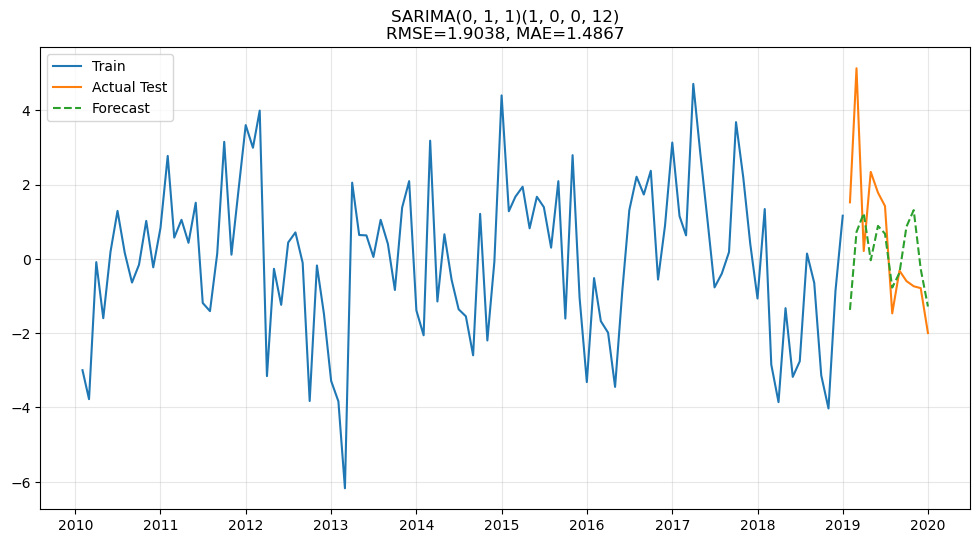

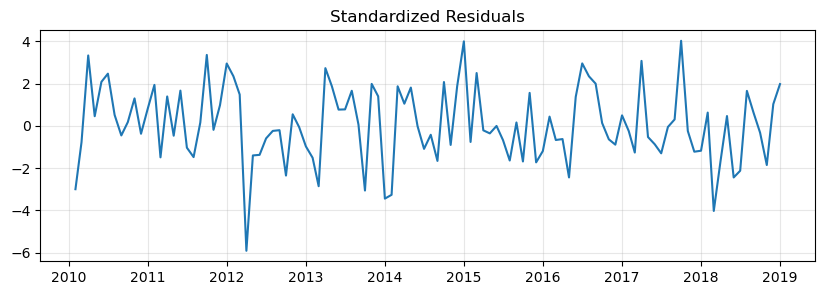

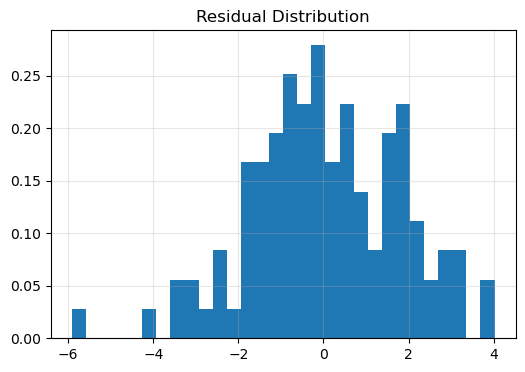

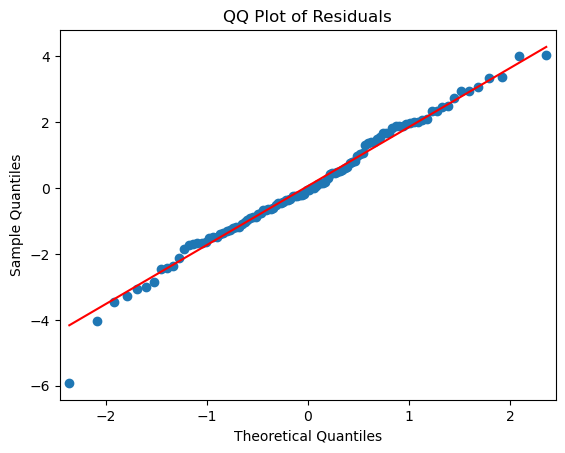

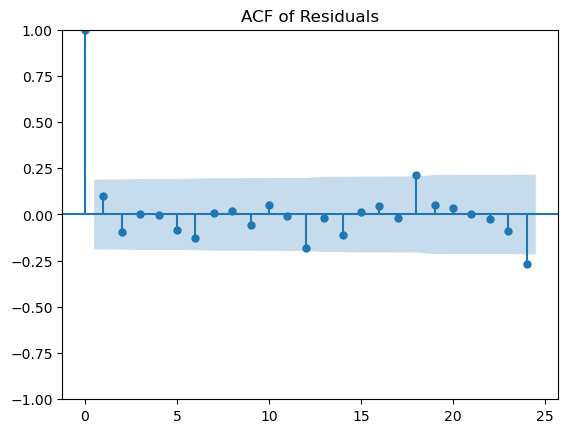

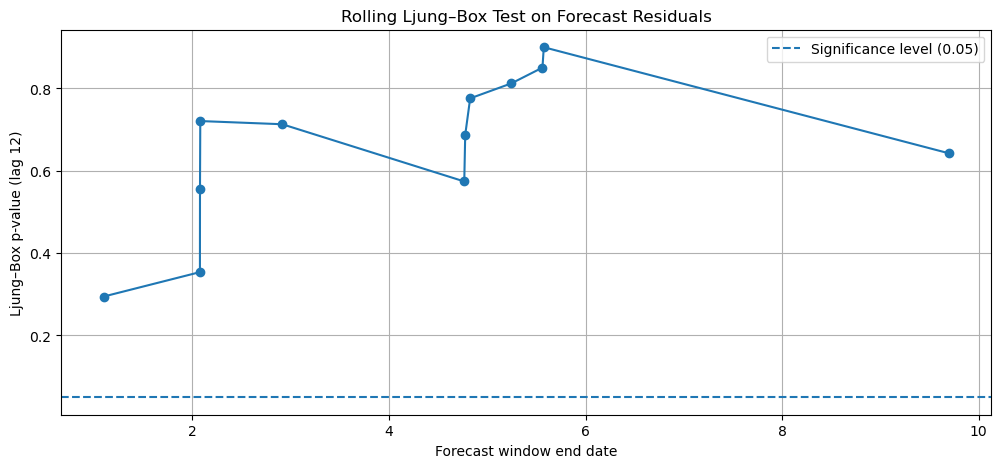

In [59]:
plot_sarimax_results(
    train=train,
    test=test,
    forecast=forecast,
    results=results,
    order=(p,d,q),
    seasonal_order=(P,D,Q,12),
    rmse=rmse,
    mae=mae,
)

In [60]:
rmse, mae, results, forecast, test, train = sarimax_experiment(data, target, p, d, q, P, D, Q, s, exog= exog)

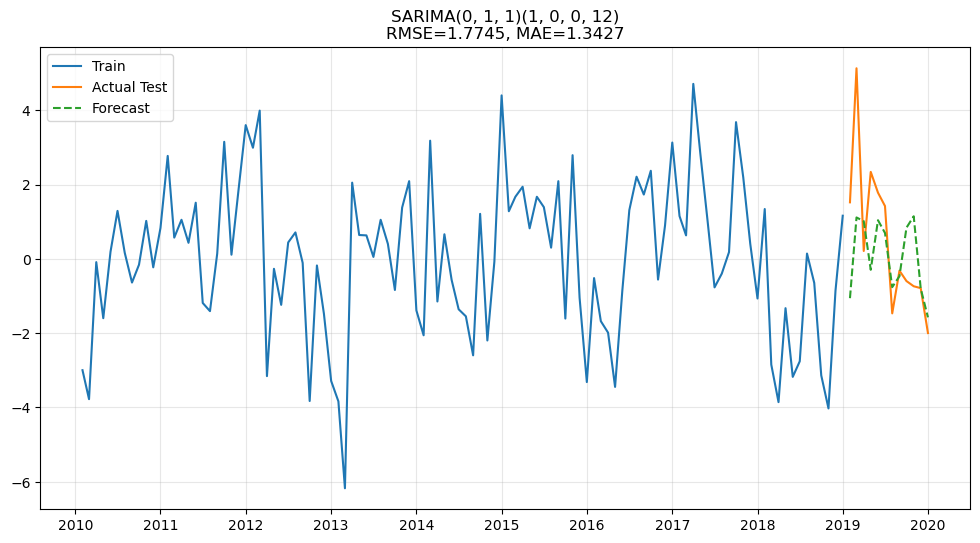

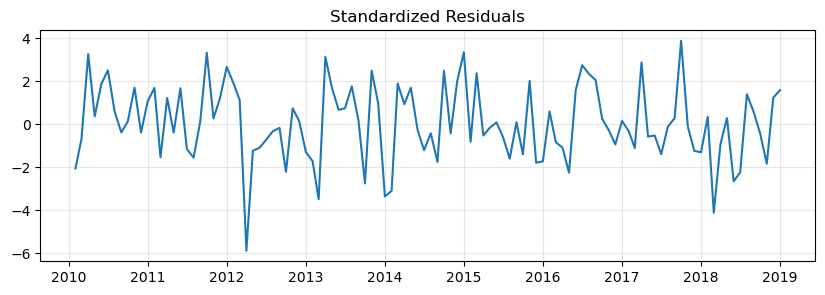

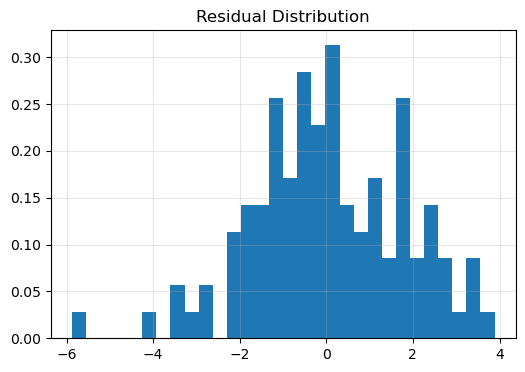

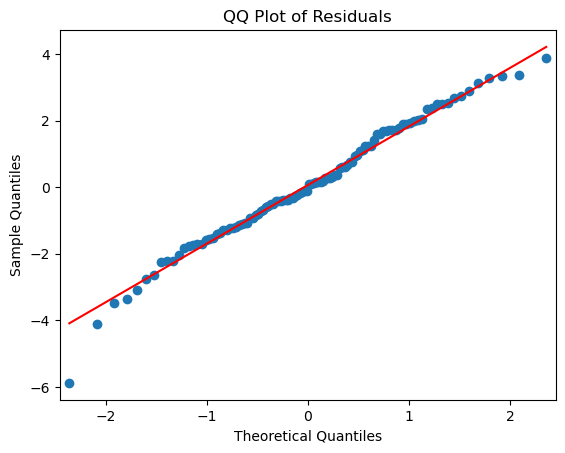

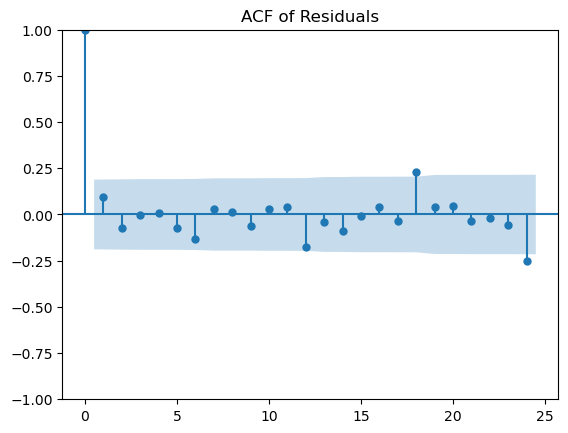

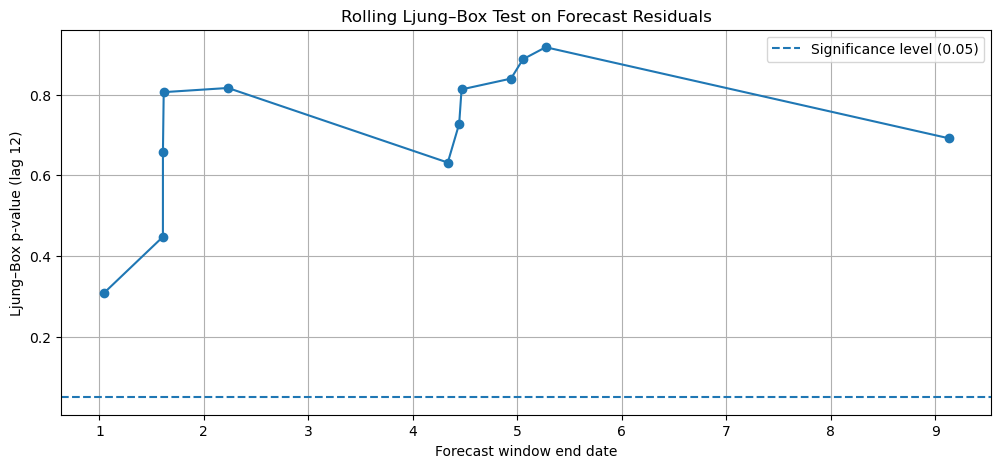

In [61]:
plot_sarimax_results(
    train=train,
    test=test,
    forecast=forecast,
    results=results,
    order=(p,d,q),
    seasonal_order=(P,D,Q,12),
    rmse=rmse,
    mae=mae,
)

In [62]:
from utils import sarima_candidates_from_acf

cand_res = sarima_candidates_from_acf(data[target], m=12, max_p=3, max_q=2, max_P=3, max_Q=3, max_lag=50)

candidates = cand_res["candidates"]
for i, (p, d, q, P, D, Q, s) in enumerate(candidates, 1):
    print(f"{i:02d}. SARIMA({p},{d},{q})({P},{D},{Q},{s})")

n: 289
NaNs: 0
var: 3.8649507046132094
01. SARIMA(0,0,0)(0,0,0,12)
02. SARIMA(0,0,0)(0,0,1,12)
03. SARIMA(0,0,0)(1,0,0,12)
04. SARIMA(0,0,0)(1,0,1,12)
05. SARIMA(0,0,0)(2,0,0,12)
06. SARIMA(0,0,0)(2,0,1,12)
07. SARIMA(0,0,0)(3,0,0,12)
08. SARIMA(0,0,0)(3,0,1,12)
09. SARIMA(0,0,1)(0,0,0,12)
10. SARIMA(0,0,1)(0,0,1,12)
11. SARIMA(0,0,1)(1,0,0,12)
12. SARIMA(0,0,1)(1,0,1,12)
13. SARIMA(0,0,1)(2,0,0,12)
14. SARIMA(0,0,1)(2,0,1,12)
15. SARIMA(0,0,1)(3,0,0,12)
16. SARIMA(0,0,1)(3,0,1,12)
17. SARIMA(0,0,2)(0,0,0,12)
18. SARIMA(0,0,2)(0,0,1,12)
19. SARIMA(0,0,2)(1,0,0,12)
20. SARIMA(0,0,2)(1,0,1,12)
21. SARIMA(0,0,2)(2,0,0,12)
22. SARIMA(0,0,2)(2,0,1,12)
23. SARIMA(0,0,2)(3,0,0,12)
24. SARIMA(0,0,2)(3,0,1,12)
25. SARIMA(1,0,0)(0,0,0,12)
26. SARIMA(1,0,0)(0,0,1,12)
27. SARIMA(1,0,0)(1,0,0,12)
28. SARIMA(1,0,0)(1,0,1,12)
29. SARIMA(1,0,0)(2,0,0,12)
30. SARIMA(1,0,0)(2,0,1,12)
31. SARIMA(1,0,0)(3,0,0,12)
32. SARIMA(1,0,0)(3,0,1,12)
33. SARIMA(1,0,1)(0,0,0,12)
34. SARIMA(1,0,1)(0,0,1,12)
35. SARIM

In [63]:
best_info, scores_df = sarimax_grid_search(
    df=data,
    target=target,
    candidates=candidates,
    forecast_window=12,
    no_windows=10,
    exog=None,    # or list of exogenous column names
    metric="rmse",
    verbose=True,
)

Tried SARIMA(0,0,0)(0,0,0,12) -> RMSE=1.9817, MAE=1.5267
Tried SARIMA(0,0,0)(0,0,1,12) -> RMSE=1.4043, MAE=0.9801
Tried SARIMA(0,0,0)(1,0,0,12) -> RMSE=1.8914, MAE=1.5974
Tried SARIMA(0,0,0)(1,0,1,12) -> RMSE=1.4171, MAE=0.9980
Tried SARIMA(0,0,0)(2,0,0,12) -> RMSE=1.9111, MAE=1.6394
Tried SARIMA(0,0,0)(2,0,1,12) -> RMSE=1.4560, MAE=1.0343
Tried SARIMA(0,0,0)(3,0,0,12) -> RMSE=1.7438, MAE=1.4461
Tried SARIMA(0,0,0)(3,0,1,12) -> RMSE=1.4612, MAE=1.0262
Tried SARIMA(0,0,1)(0,0,0,12) -> RMSE=1.9616, MAE=1.4972
Tried SARIMA(0,0,1)(0,0,1,12) -> RMSE=1.3203, MAE=0.9317
Tried SARIMA(0,0,1)(1,0,0,12) -> RMSE=1.8736, MAE=1.5820
Tried SARIMA(0,0,1)(1,0,1,12) -> RMSE=1.3172, MAE=0.9288
Tried SARIMA(0,0,1)(2,0,0,12) -> RMSE=1.8589, MAE=1.6117
Tried SARIMA(0,0,1)(2,0,1,12) -> RMSE=1.3071, MAE=0.9122
Tried SARIMA(0,0,1)(3,0,0,12) -> RMSE=1.7056, MAE=1.4399
Tried SARIMA(0,0,1)(3,0,1,12) -> RMSE=1.3532, MAE=0.9606
Tried SARIMA(0,0,2)(0,0,0,12) -> RMSE=1.9255, MAE=1.4754
Tried SARIMA(0,0,2)(0,0,1,12) -

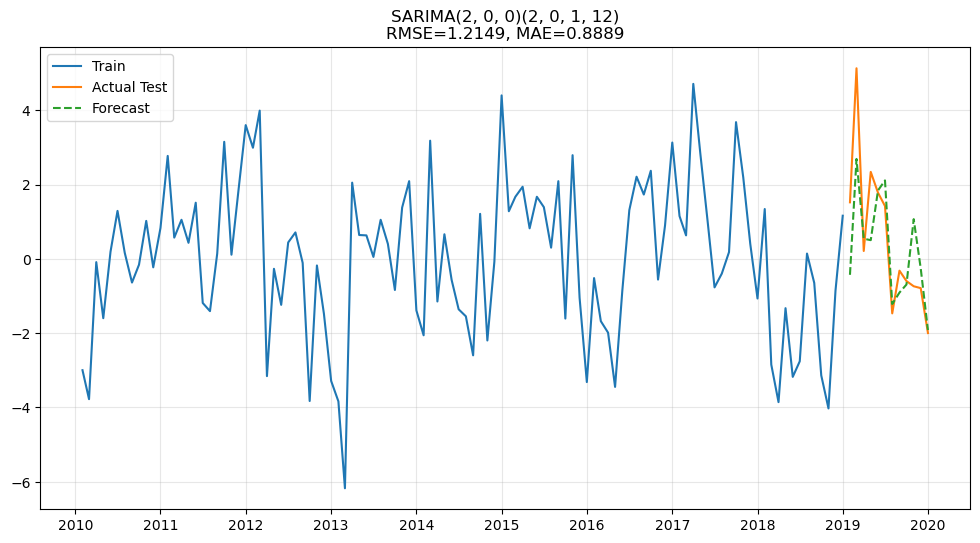

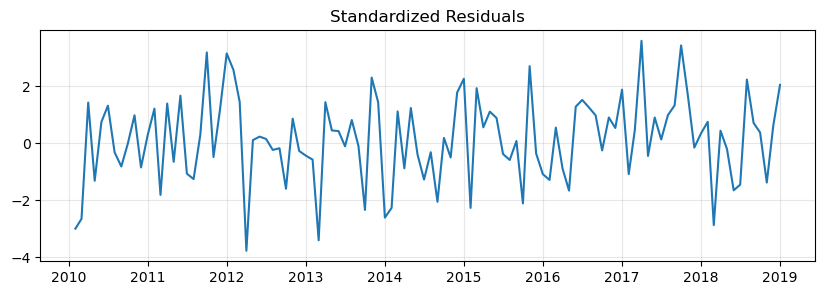

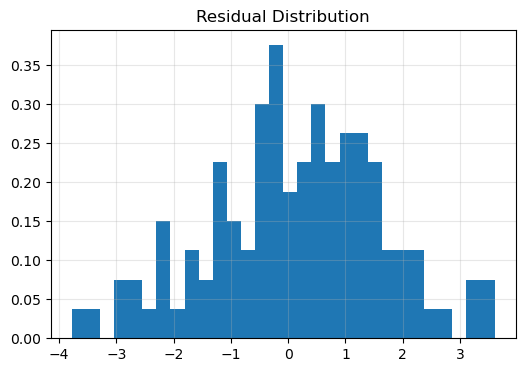

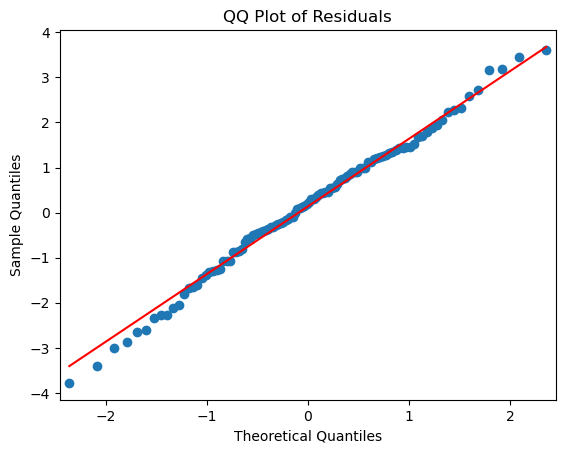

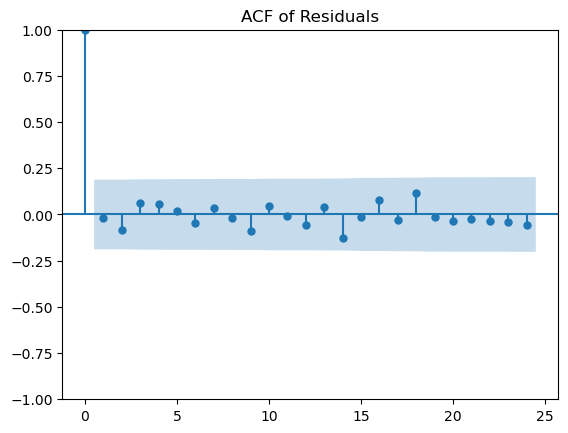

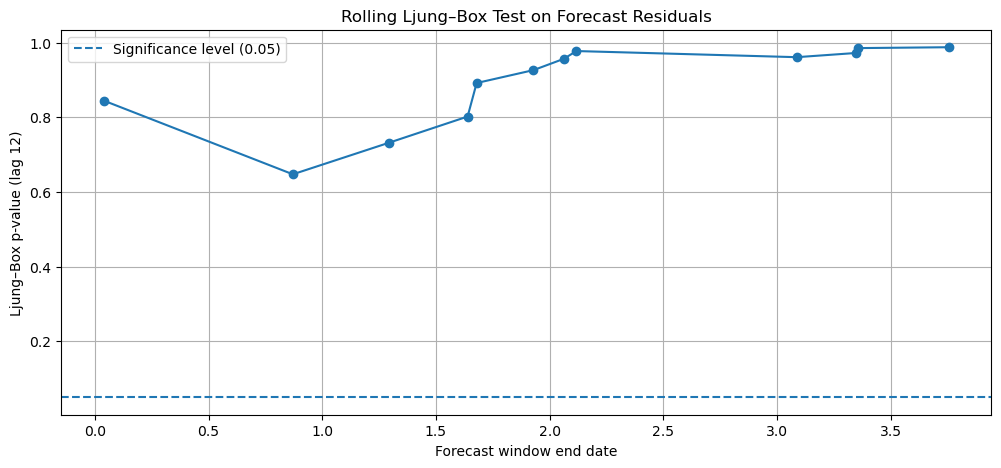

In [64]:
plot_sarimax_results(
    train=best_info["train"],
    test=best_info["test"],
    forecast=best_info["forecast"],
    results=best_info["results"],
    order=best_info["order"],
    seasonal_order=best_info["seasonal_order"],
    rmse=best_info["rmse"],
    mae=best_info["mae"],
)

In [65]:
best_info, scores_df = sarimax_grid_search(
    df=data,
    target=target,
    candidates=candidates,
    forecast_window=12,
    no_windows=10,
    exog=None,    
    metric="rmse",
    verbose=True,
)

Tried SARIMA(0,0,0)(0,0,0,12) -> RMSE=1.9817, MAE=1.5267
Tried SARIMA(0,0,0)(0,0,1,12) -> RMSE=1.4043, MAE=0.9801
Tried SARIMA(0,0,0)(1,0,0,12) -> RMSE=1.8914, MAE=1.5974
Tried SARIMA(0,0,0)(1,0,1,12) -> RMSE=1.4171, MAE=0.9980
Tried SARIMA(0,0,0)(2,0,0,12) -> RMSE=1.9111, MAE=1.6394
Tried SARIMA(0,0,0)(2,0,1,12) -> RMSE=1.4560, MAE=1.0343
Tried SARIMA(0,0,0)(3,0,0,12) -> RMSE=1.7438, MAE=1.4461
Tried SARIMA(0,0,0)(3,0,1,12) -> RMSE=1.4612, MAE=1.0262
Tried SARIMA(0,0,1)(0,0,0,12) -> RMSE=1.9616, MAE=1.4972
Tried SARIMA(0,0,1)(0,0,1,12) -> RMSE=1.3203, MAE=0.9317
Tried SARIMA(0,0,1)(1,0,0,12) -> RMSE=1.8736, MAE=1.5820
Tried SARIMA(0,0,1)(1,0,1,12) -> RMSE=1.3172, MAE=0.9288
Tried SARIMA(0,0,1)(2,0,0,12) -> RMSE=1.8589, MAE=1.6117
Tried SARIMA(0,0,1)(2,0,1,12) -> RMSE=1.3071, MAE=0.9122
Tried SARIMA(0,0,1)(3,0,0,12) -> RMSE=1.7056, MAE=1.4399
Tried SARIMA(0,0,1)(3,0,1,12) -> RMSE=1.3532, MAE=0.9606
Tried SARIMA(0,0,2)(0,0,0,12) -> RMSE=1.9255, MAE=1.4754
Tried SARIMA(0,0,2)(0,0,1,12) -

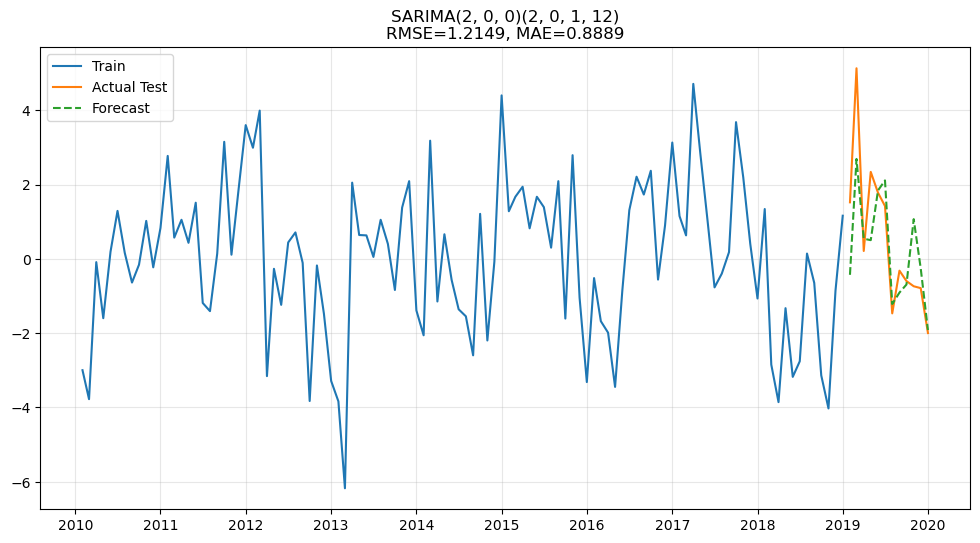

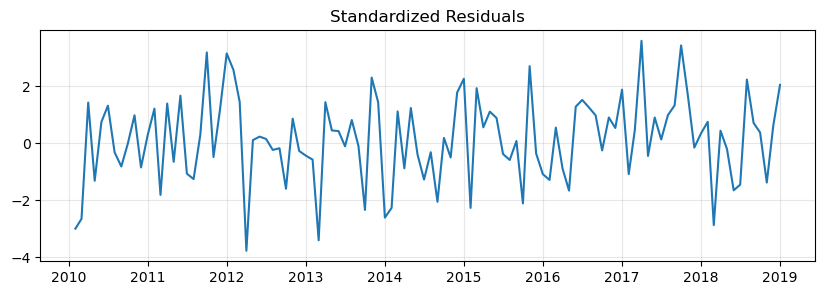

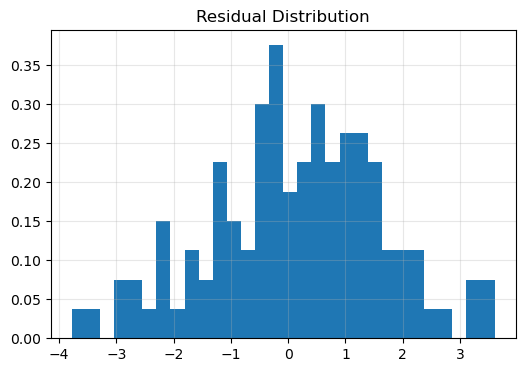

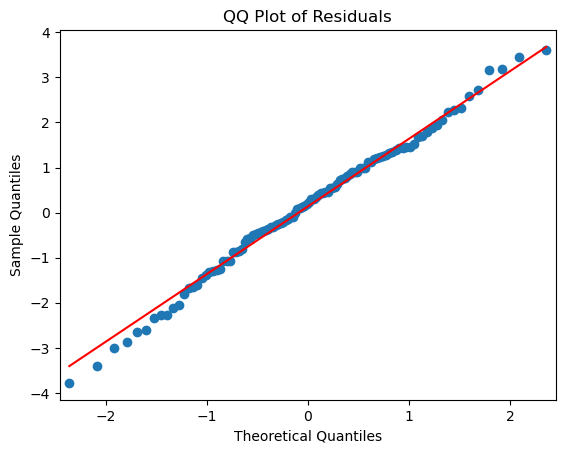

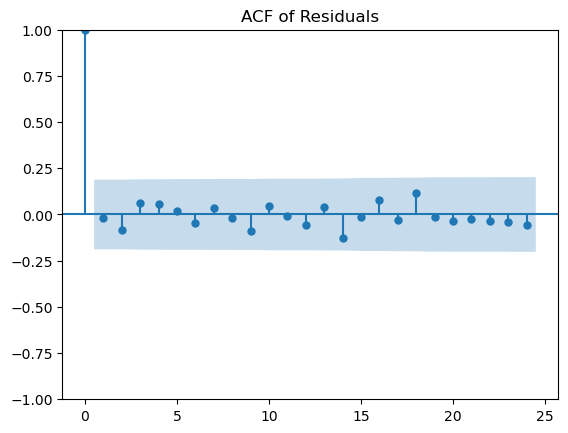

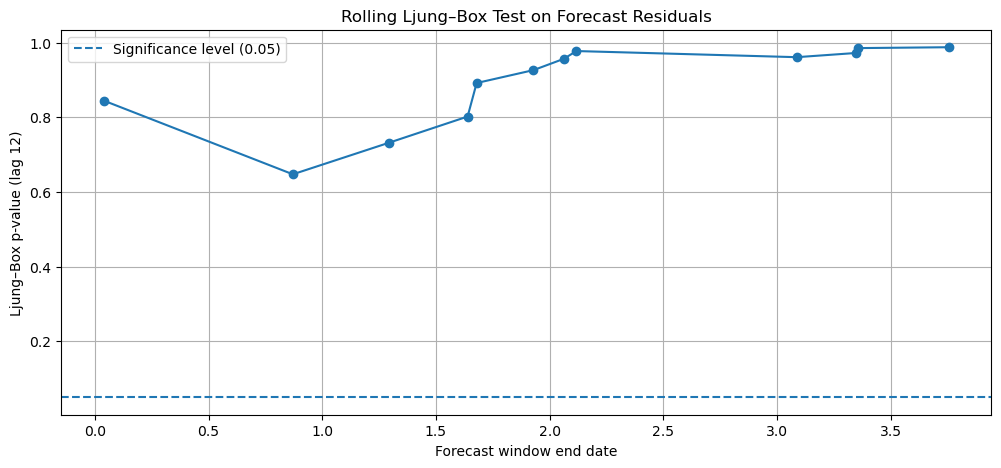

In [66]:
plot_sarimax_results(
    train=train,
    test=best_info["test"],
    forecast=best_info["forecast"],
    results=best_info["results"],
    order=best_info["order"],
    seasonal_order=best_info["seasonal_order"],
    rmse=best_info["rmse"],
    mae=best_info["mae"],
)

In [67]:
best_info, scores_df = sarimax_grid_search(
    df=data,
    target=target,
    candidates=candidates,
    forecast_window=12,
    no_windows=10,
    exog=exog,    # or list of exogenous column names
    metric="rmse",
    verbose=True,
)

Tried SARIMA(0,0,0)(0,0,0,12) -> RMSE=1.9692, MAE=1.4945
Tried SARIMA(0,0,0)(0,0,1,12) -> RMSE=1.4554, MAE=1.2207
Tried SARIMA(0,0,0)(1,0,0,12) -> RMSE=1.9396, MAE=1.6611
Tried SARIMA(0,0,0)(1,0,1,12) -> RMSE=1.4870, MAE=1.2675
Tried SARIMA(0,0,0)(2,0,0,12) -> RMSE=2.0054, MAE=1.7965
Tried SARIMA(0,0,0)(2,0,1,12) -> RMSE=1.4517, MAE=1.2077
Tried SARIMA(0,0,0)(3,0,0,12) -> RMSE=1.8410, MAE=1.6240
Tried SARIMA(0,0,0)(3,0,1,12) -> RMSE=1.9156, MAE=1.7103
Tried SARIMA(0,0,1)(0,0,0,12) -> RMSE=1.9536, MAE=1.4848
Tried SARIMA(0,0,1)(0,0,1,12) -> RMSE=1.3804, MAE=1.1680
Tried SARIMA(0,0,1)(1,0,0,12) -> RMSE=1.9143, MAE=1.6335
Tried SARIMA(0,0,1)(1,0,1,12) -> RMSE=1.4303, MAE=1.2335
Tried SARIMA(0,0,1)(2,0,0,12) -> RMSE=1.9450, MAE=1.7551
Tried SARIMA(0,0,1)(2,0,1,12) -> RMSE=1.4214, MAE=1.2036
Tried SARIMA(0,0,1)(3,0,0,12) -> RMSE=1.7966, MAE=1.6040
Tried SARIMA(0,0,1)(3,0,1,12) -> RMSE=1.5478, MAE=1.2400
Tried SARIMA(0,0,2)(0,0,0,12) -> RMSE=1.9164, MAE=1.4600
Tried SARIMA(0,0,2)(0,0,1,12) -

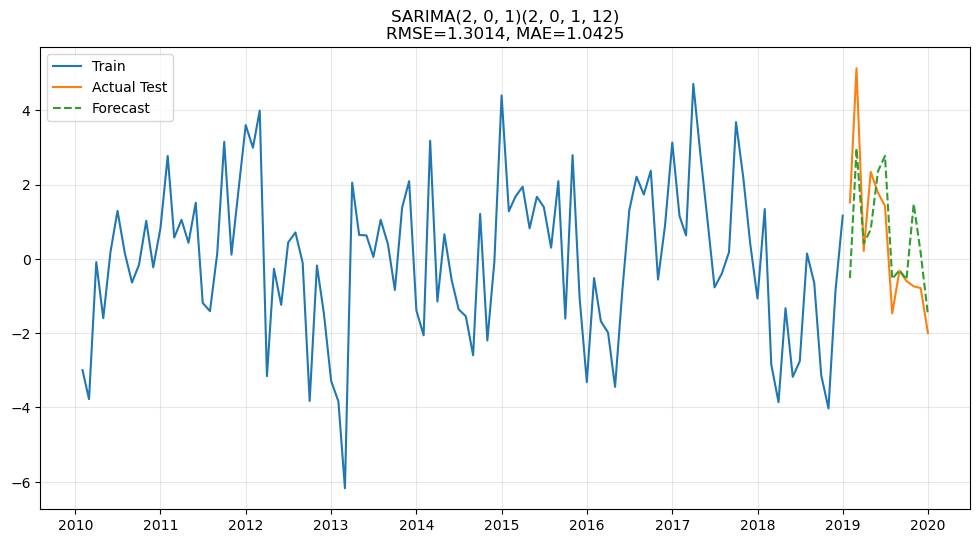

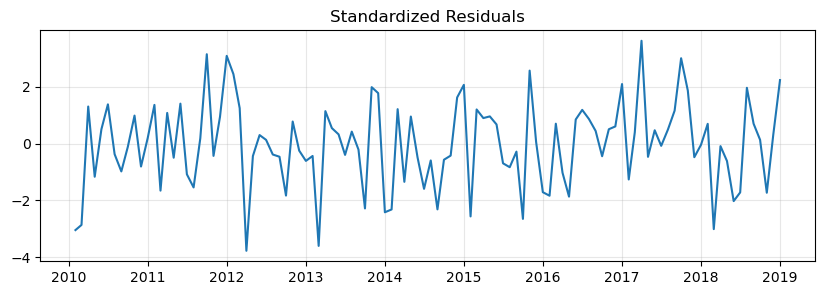

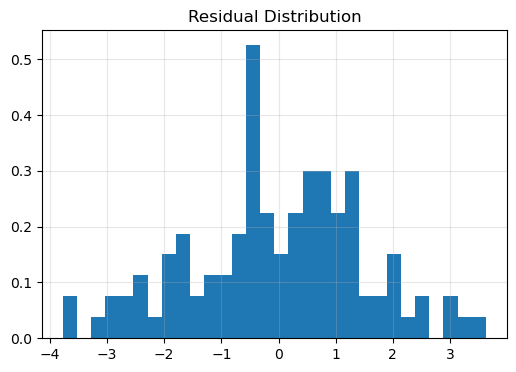

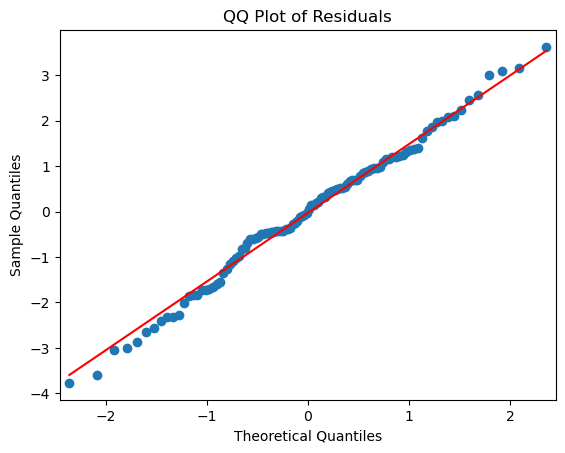

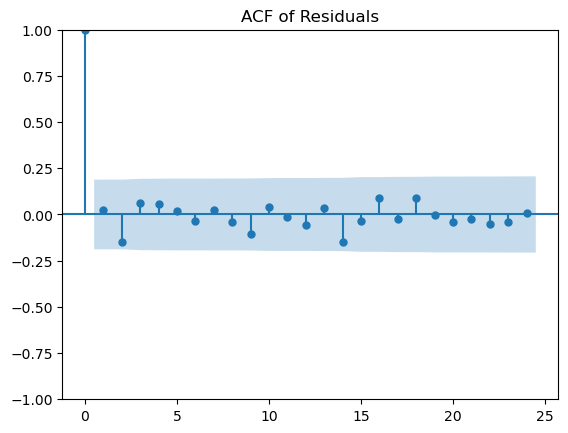

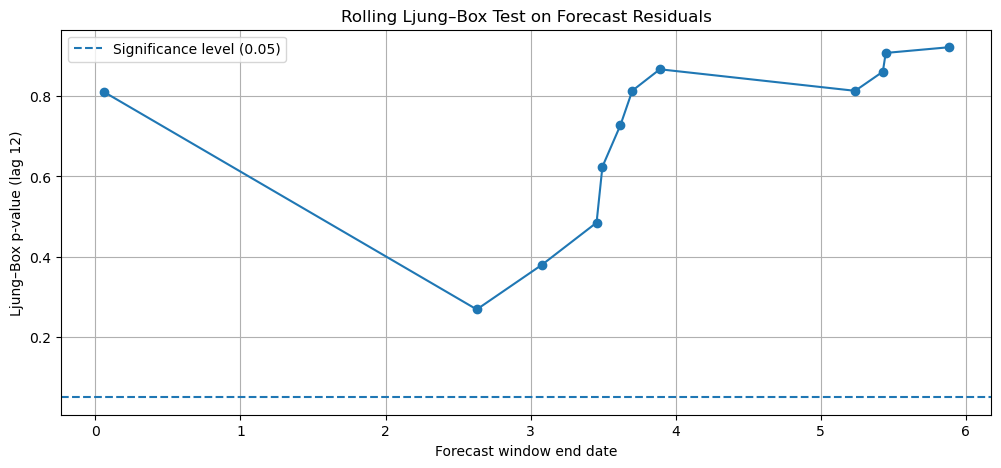

In [68]:
plot_sarimax_results(
    train=best_info["train"],
    test=best_info["test"],
    forecast=best_info["forecast"],
    results=best_info["results"],
    order=best_info["order"],
    seasonal_order=best_info["seasonal_order"],
    rmse=best_info["rmse"],
    mae=best_info["mae"],
)

# Using AutoSarima with the current train/test split

In [69]:
rmse, mae, results, forecast, test, train, order, seasonal_order = auto_sarima_experiment(data, target, forecast_window=12, no_windows=10, m=12)

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=469.308, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=427.768, Time=0.11 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=inf, Time=0.06 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=467.308, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=456.406, Time=0.01 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=416.027, Time=0.06 sec
 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=inf, Time=0.30 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.10 sec
 ARIMA(0,0,0)(2,0,0)[12] intercept   : AIC=426.858, Time=0.04 sec
 ARIMA(2,0,0)(2,0,0)[12] intercept   : AIC=417.956, Time=0.06 sec
 ARIMA(1,0,1)(2,0,0)[12] intercept   : AIC=417.660, Time=0.09 sec
 ARIMA(0,0,1)(2,0,0)[12] intercept   : AIC=417.038, Time=0.06 sec
 ARIMA(2,0,1)(2,0,0)[12] intercept   : AIC=419.155, Time=0.26 sec
 ARIMA(1,0,0)(2,0,0)[12]             : AIC=414.781, Time=0.03 sec
 ARIMA(1,0,0)(1,0,0)[12]             : AIC=42

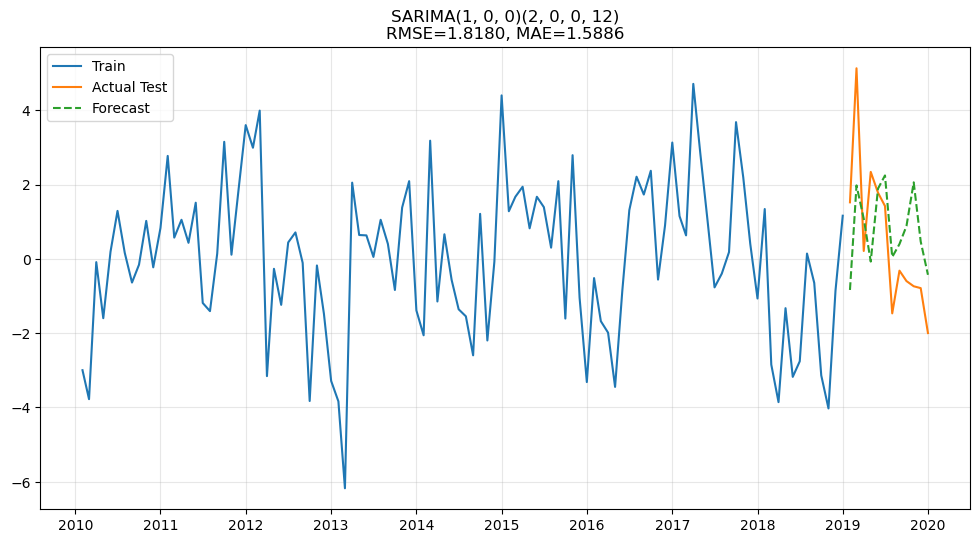

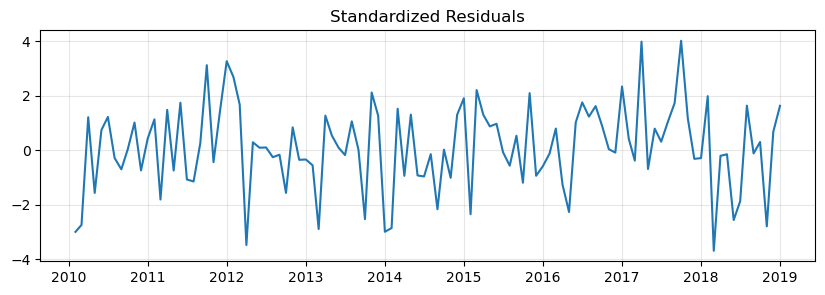

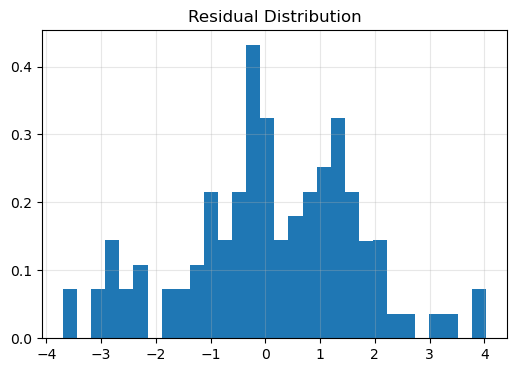

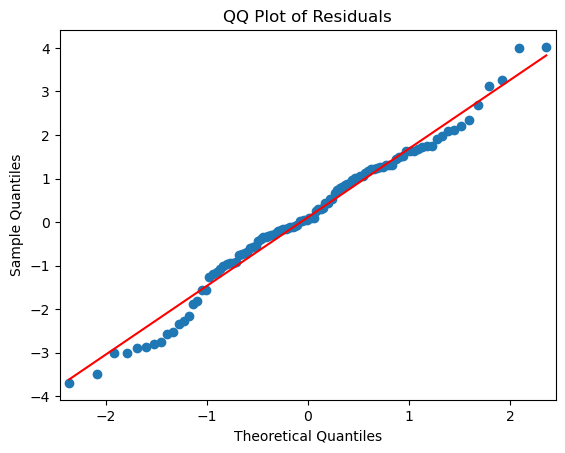

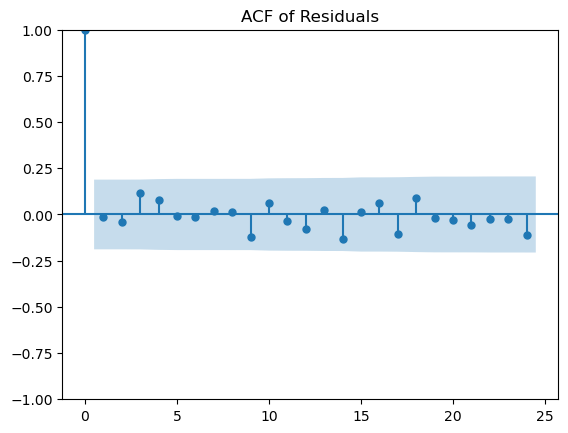

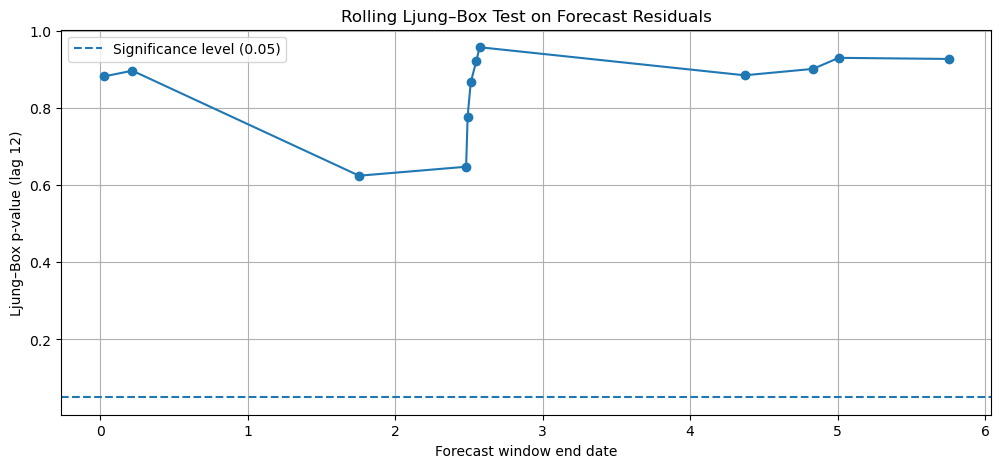

In [70]:
plot_sarimax_results(
    train=train,
    test=test,
    forecast=forecast,
    results=results,
    order=order,
    seasonal_order=seasonal_order,
    rmse=rmse,
    mae=mae,
)

In [71]:
rmse, mae, results, forecast, test, train, order, seasonal_order = auto_sarima_experiment(data, target, forecast_window=12, no_windows=10, m=12, exog=exog)

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=469.308, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=427.768, Time=0.03 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=inf, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=467.308, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=456.406, Time=0.01 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=416.027, Time=0.06 sec
 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=inf, Time=0.29 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.12 sec
 ARIMA(0,0,0)(2,0,0)[12] intercept   : AIC=426.858, Time=0.04 sec
 ARIMA(2,0,0)(2,0,0)[12] intercept   : AIC=417.956, Time=0.07 sec
 ARIMA(1,0,1)(2,0,0)[12] intercept   : AIC=417.660, Time=0.09 sec
 ARIMA(0,0,1)(2,0,0)[12] intercept   : AIC=417.038, Time=0.05 sec
 ARIMA(2,0,1)(2,0,0)[12] intercept   : AIC=419.155, Time=0.21 sec
 ARIMA(1,0,0)(2,0,0)[12]             : AIC=414.781, Time=0.05 sec
 ARIMA(1,0,0)(1,0,0)[12]             : AIC=42

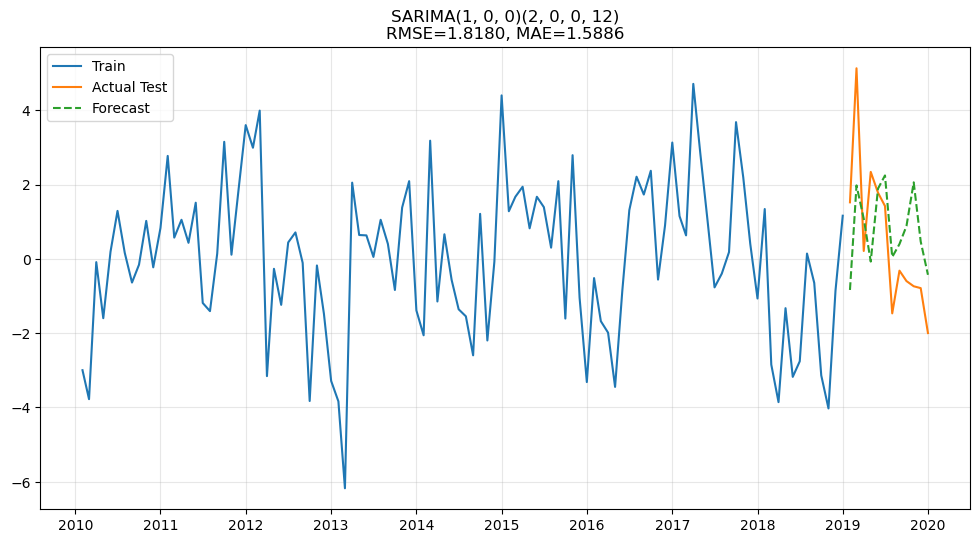

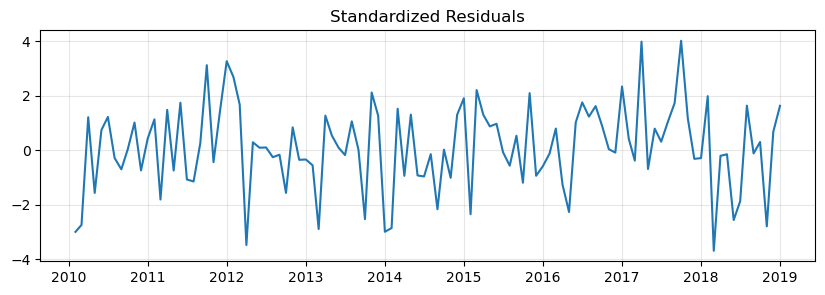

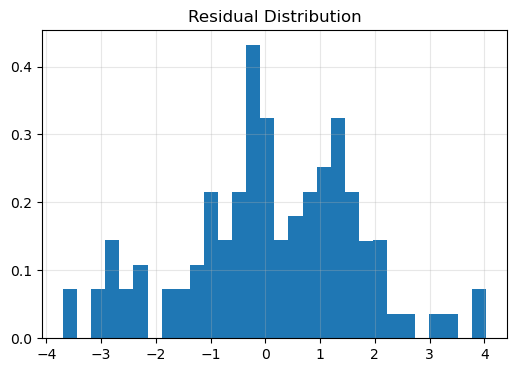

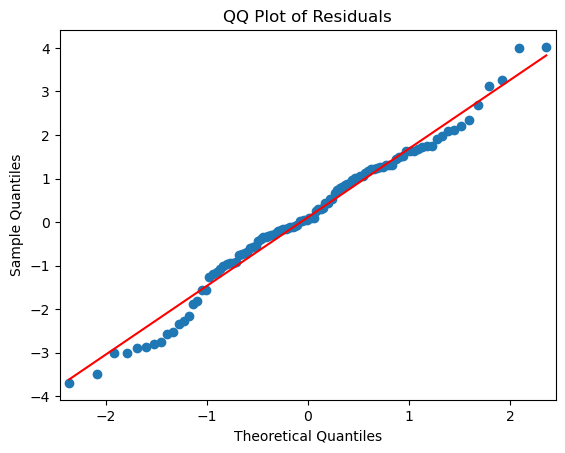

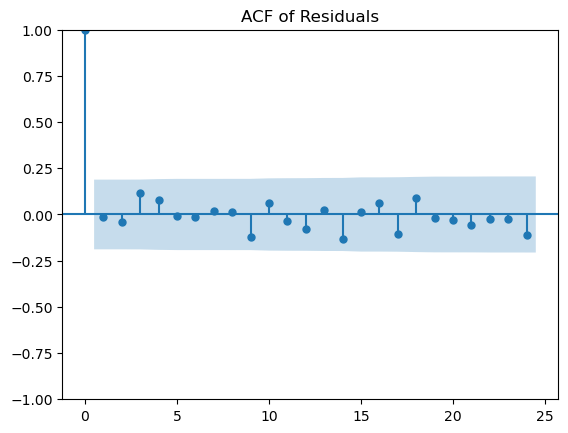

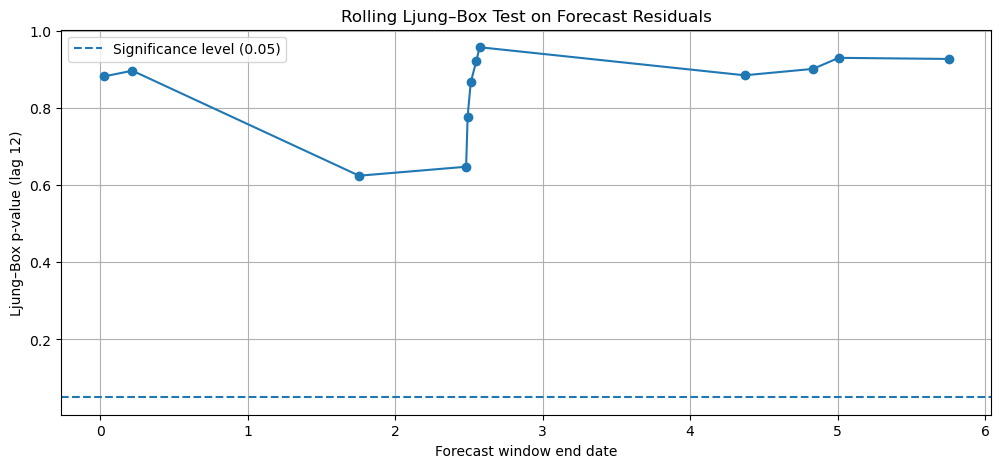

In [72]:
plot_sarimax_results(
    train=train,
    test=test,
    forecast=forecast,
    results=results,
    order=order,
    seasonal_order=seasonal_order,
    rmse=rmse,
    mae=mae,
)

In [73]:
h = 12
years_test = 2
years_train = 8
forecast_window = h * years_test
step = h
train_size = h * years_train
best_info, scores_df  = select_best_sarima_cv(
    data,
    target,
    candidates=candidates,
    forecast_window=forecast_window,
    train_size=train_size,
    step=step,
    exog=None,
)

Running rolling CV with 15 folds...
01. SARIMA(0,0,0)(0,0,0,12) - mean RMSE=1.9296, mean MAE=1.5371
Running rolling CV with 15 folds...
02. SARIMA(0,0,0)(0,0,1,12) - mean RMSE=1.7032, mean MAE=1.3383
Running rolling CV with 15 folds...
03. SARIMA(0,0,0)(1,0,0,12) - mean RMSE=1.8552, mean MAE=1.4352
Running rolling CV with 15 folds...
04. SARIMA(0,0,0)(1,0,1,12) - mean RMSE=1.7343, mean MAE=1.3570
Running rolling CV with 15 folds...
05. SARIMA(0,0,0)(2,0,0,12) - mean RMSE=1.7760, mean MAE=1.4178
Running rolling CV with 15 folds...
06. SARIMA(0,0,0)(2,0,1,12) - mean RMSE=1.7560, mean MAE=1.4068
Running rolling CV with 15 folds...
07. SARIMA(0,0,0)(3,0,0,12) - mean RMSE=1.7711, mean MAE=1.4121
Running rolling CV with 15 folds...
08. SARIMA(0,0,0)(3,0,1,12) - mean RMSE=1.7959, mean MAE=1.4427
Running rolling CV with 15 folds...
09. SARIMA(0,0,1)(0,0,0,12) - mean RMSE=1.9242, mean MAE=1.5341
Running rolling CV with 15 folds...
10. SARIMA(0,0,1)(0,0,1,12) - mean RMSE=1.6950, mean MAE=1.3304


In [74]:
p, d, q = best_info["order"][0] , best_info["order"][1], best_info["order"][2]
P, D, Q, s = best_info["seasonal_order"][0], best_info["seasonal_order"][1], best_info["seasonal_order"][2], best_info["seasonal_order"][3]
rmse, mae, results_train, forecast, test, train = sarimax_experiment(data, target, p, d, q, P, D, Q, s)

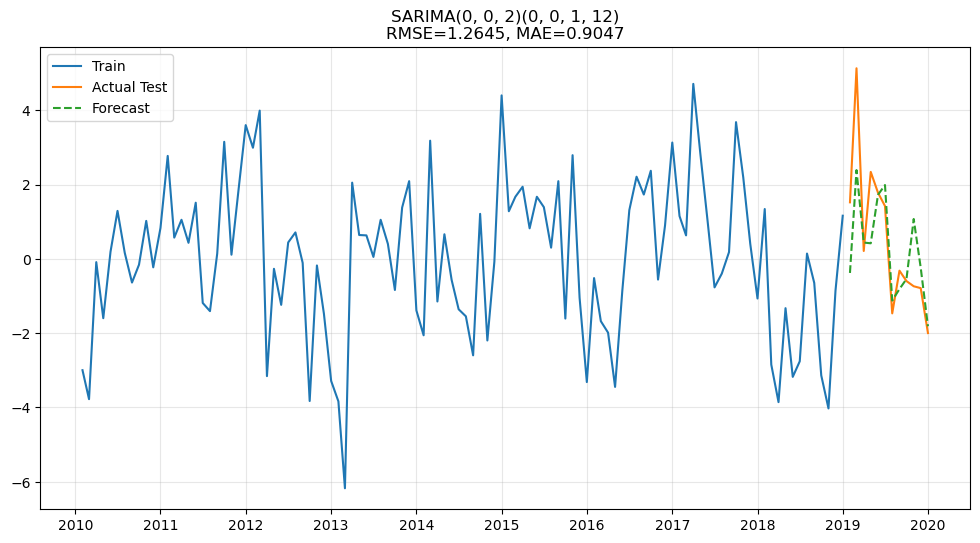

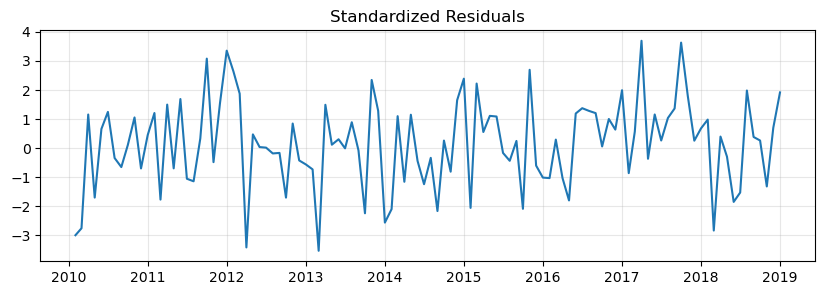

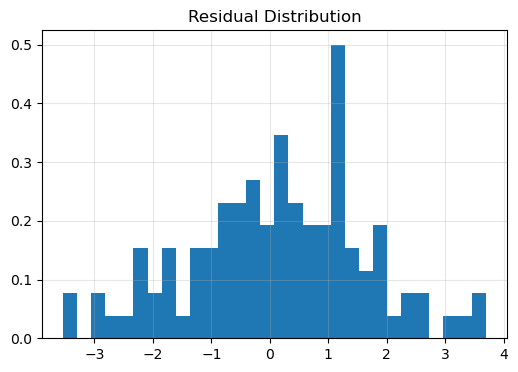

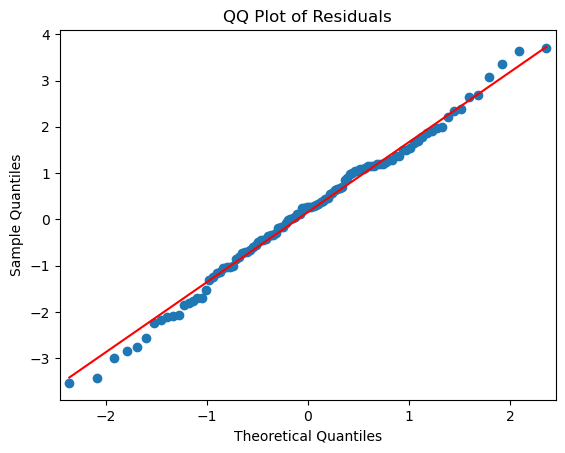

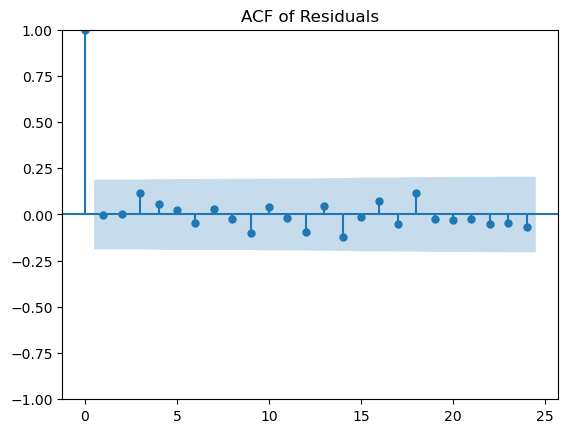

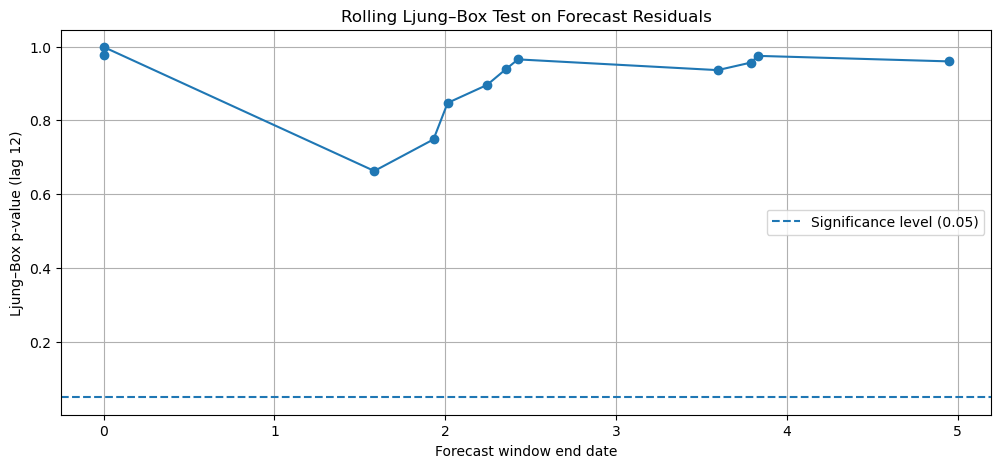

In [75]:
plot_sarimax_results(
    train=train,
    test=test,
    forecast=forecast,
    results=results_train,     # ✅ use results_train
    order=(p, d, q),
    seasonal_order=(P, D, Q, s),
    rmse=rmse,
    mae=mae,
)

In [76]:
best_info, scores_df  = select_best_sarima_cv(
    data,
    target,
    candidates=candidates,
    forecast_window=forecast_window,
    train_size=train_size,
    step=step,
    exog=exog,
)

Running rolling CV with 15 folds...
01. SARIMA(0,0,0)(0,0,0,12) - mean RMSE=1.9327, mean MAE=1.5427
Running rolling CV with 15 folds...
02. SARIMA(0,0,0)(0,0,1,12) - mean RMSE=1.7281, mean MAE=1.3572
Running rolling CV with 15 folds...
03. SARIMA(0,0,0)(1,0,0,12) - mean RMSE=1.8593, mean MAE=1.4511
Running rolling CV with 15 folds...
04. SARIMA(0,0,0)(1,0,1,12) - mean RMSE=1.7519, mean MAE=1.3711
Running rolling CV with 15 folds...
05. SARIMA(0,0,0)(2,0,0,12) - mean RMSE=1.7934, mean MAE=1.4312
Running rolling CV with 15 folds...
06. SARIMA(0,0,0)(2,0,1,12) - mean RMSE=1.7738, mean MAE=1.4112
Running rolling CV with 15 folds...
07. SARIMA(0,0,0)(3,0,0,12) - mean RMSE=1.8005, mean MAE=1.4317
Running rolling CV with 15 folds...
08. SARIMA(0,0,0)(3,0,1,12) - mean RMSE=1.8113, mean MAE=1.4466
Running rolling CV with 15 folds...
09. SARIMA(0,0,1)(0,0,0,12) - mean RMSE=1.9356, mean MAE=1.5463
Running rolling CV with 15 folds...
10. SARIMA(0,0,1)(0,0,1,12) - mean RMSE=1.7206, mean MAE=1.3510


In [77]:
p, d, q = best_info["order"][0] , best_info["order"][1], best_info["order"][2]
P, D, Q, s = best_info["seasonal_order"][0], best_info["seasonal_order"][1], best_info["seasonal_order"][2], best_info["seasonal_order"][3]
rmse, mae, results_train, forecast, test, train = sarimax_experiment(data, target, p, d, q, P, D, Q, s)

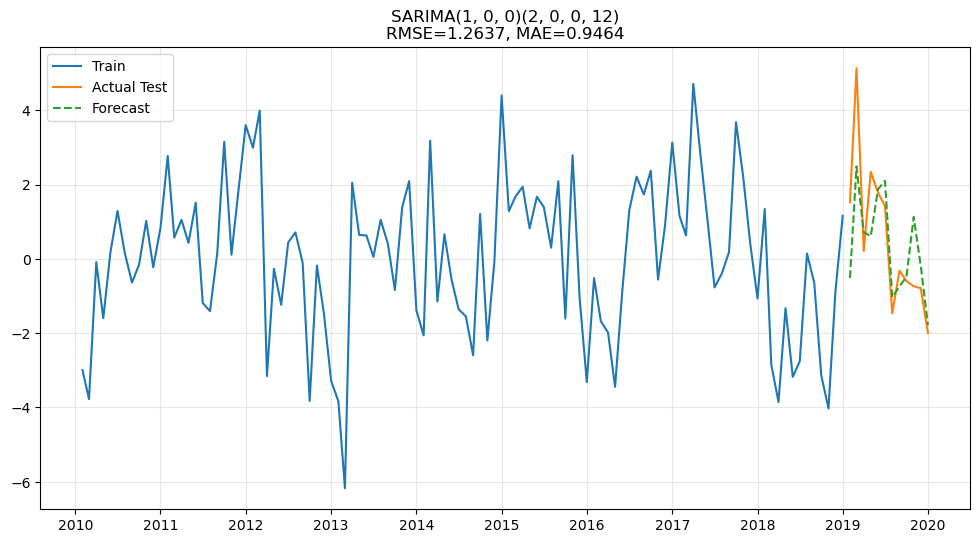

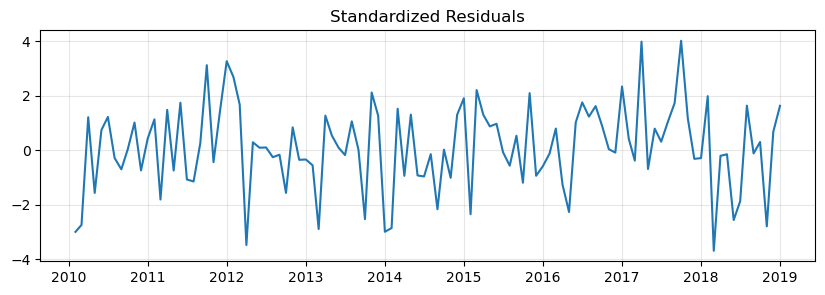

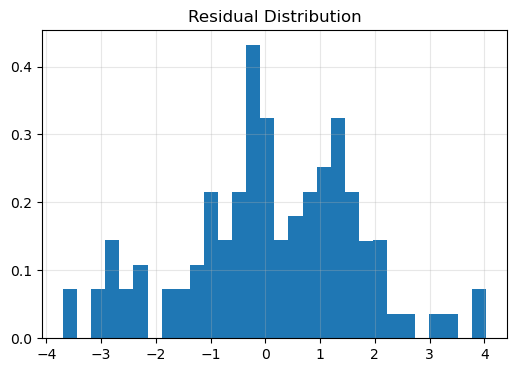

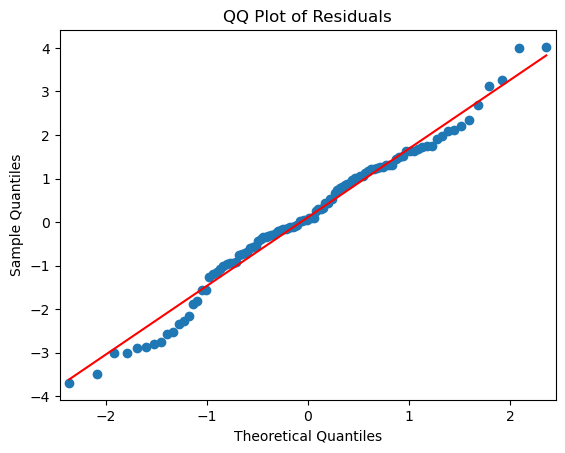

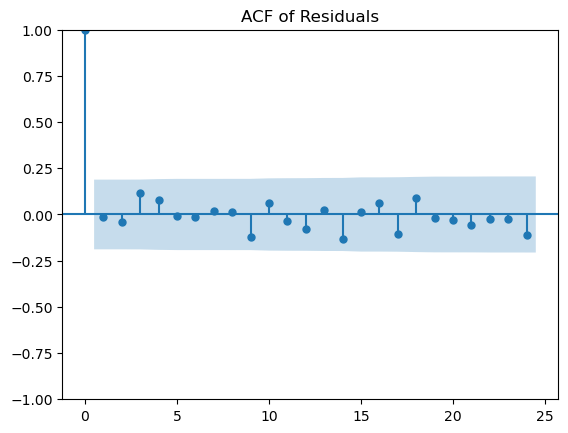

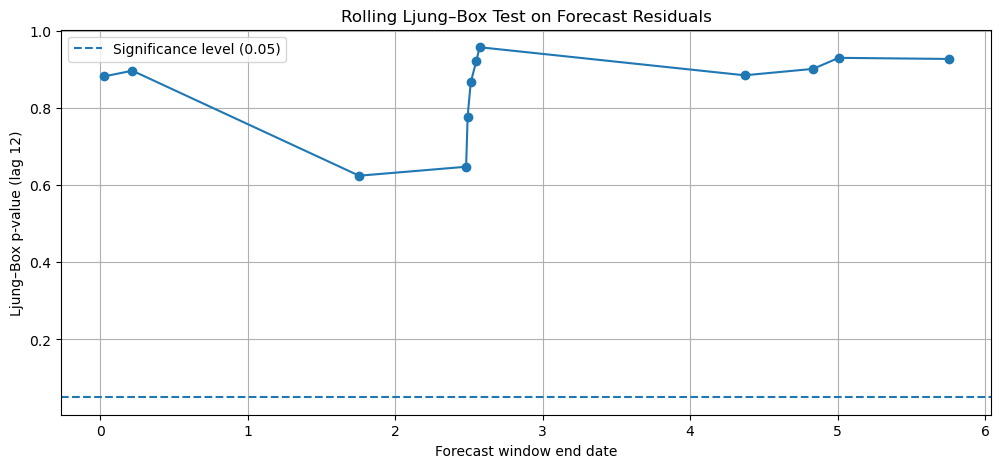

In [78]:
plot_sarimax_results(
    train=train,
    test=test,
    forecast=forecast,
    results=results,
    order=order,
    seasonal_order=seasonal_order,
    rmse=rmse,
    mae=mae,
)